In [ ]:
#RNNvsLSTMvsGRU
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, SimpleRNN, LSTM, GRU

In [ ]:
import pandas as pd
df = pd.read_csv("/content/IMDB Dataset.csv")

print(df.head())
print(df.isnull().sum())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
review       0
sentiment    0
dtype: int64


In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)   # remove HTML tags
    text = re.sub(r'[^a-zA-Z]', ' ', text)  # keep only letters
    return text

df['review'] = df['review'].apply(clean_text)

In [ ]:
encoder = LabelEncoder()
df['sentiment'] = encoder.fit_transform(df['sentiment'])

X = df['review']
y = df['sentiment']

In [ ]:
max_words = 10000
max_len = 200

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X)

X_seq = tokenizer.texts_to_sequences(X)
X_pad = pad_sequences(X_seq, maxlen=max_len, padding='post', truncating='post')

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pad, y, test_size=0.2, random_state=42
)

In [ ]:
rnn_model = Sequential([
    Embedding(max_words, 128),
    SimpleRNN(64),
    Dense(1, activation='sigmoid')
])

rnn_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=128,
    validation_data=(X_test, y_test)
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 135ms/step - accuracy: 0.5051 - loss: 0.6948 - val_accuracy: 0.5111 - val_loss: 0.6919
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 43s 137ms/step - accuracy: 0.5980 - loss: 0.6415 - val_accuracy: 0.5405 - val_loss: 0.6934
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 135ms/step - accuracy: 0.6872 - loss: 0.4926 - val_accuracy: 0.4978 - val_loss: 0.8287
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 131ms/step - accuracy: 0.7219 - loss: 0.4221 - val_accuracy: 0.4946 - val_loss: 0.9859
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 134ms/step - accuracy: 0.7458 - loss: 0.3753 - val_accuracy: 0.5035 - val_loss: 1.1046


In [ ]:
lstm_model = Sequential([
    Embedding(max_words, 128),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=128,
    validation_data=(X_test, y_test)
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 130s 410ms/step - accuracy: 0.5729 - loss: 0.6795 - val_accuracy: 0.5660 - val_loss: 0.6785
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 143s 413ms/step - accuracy: 0.6089 - loss: 0.6517 - val_accuracy: 0.7247 - val_loss: 0.5830
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 138s 401ms/step - accuracy: 0.7213 - loss: 0.5596 - val_accuracy: 0.8002 - val_loss: 0.4710
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 145s 409ms/step - accuracy: 0.8257 - loss: 0.4185 - val_accuracy: 0.8244 - val_loss: 0.4090
Epoch 5/5
304/313 ━━━━━━━━━━━━━━━━━━━━ 3s 389ms/step - accuracy: 0.8371 - loss: 0.3838

In [ ]:
gru_model = Sequential([
    Embedding(max_words, 128),
    GRU(64),
    Dense(1, activation='sigmoid')
])

gru_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

gru_history = gru_model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=128,
    validation_data=(X_test, y_test)
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 144s 452ms/step - accuracy: 0.5259 - loss: 0.6927 - val_accuracy: 0.5464 - val_loss: 0.6809
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 140s 449ms/step - accuracy: 0.7060 - loss: 0.5817 - val_accuracy: 0.7537 - val_loss: 0.5359
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 139s 442ms/step - accuracy: 0.8075 - loss: 0.4390 - val_accuracy: 0.8388 - val_loss: 0.3939
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 142s 442ms/step - accuracy: 0.8886 - loss: 0.2782 - val_accuracy: 0.8720 - val_loss: 0.3008
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 139s 444ms/step - accuracy: 0.9272 - loss: 0.1979 - val_accuracy: 0.8778 - val_loss: 0.3018


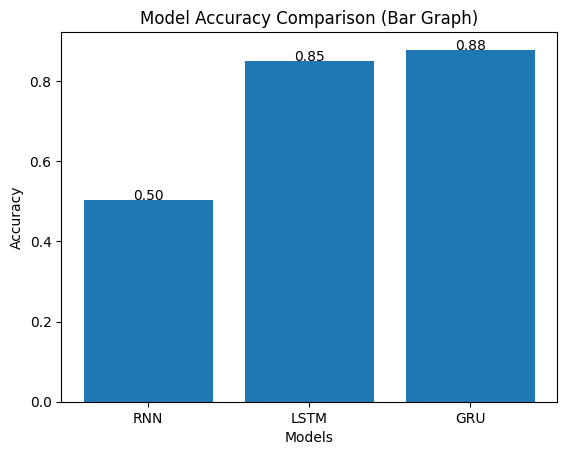

In [ ]:
# Get final validation accuracy (last epoch)
rnn_acc = rnn_history.history['val_accuracy'][-1]
lstm_acc = lstm_history.history['val_accuracy'][-1]
gru_acc = gru_history.history['val_accuracy'][-1]

models = ['RNN', 'LSTM', 'GRU']
accuracies = [rnn_acc, lstm_acc, gru_acc]

plt.figure()
plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison (Bar Graph)")
plt.xlabel("Models")
plt.ylabel("Accuracy")

# Show values on top
for i, v in enumerate(accuracies):
    plt.text(i, v, f"{v:.2f}", ha='center')

plt.show()

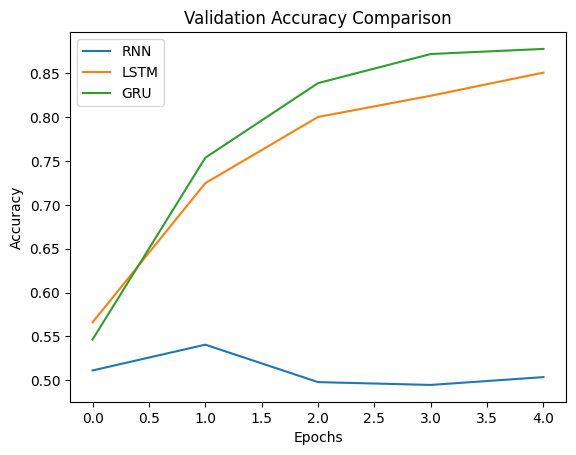

In [ ]:
plt.figure()

plt.plot(rnn_history.history['val_accuracy'], label='RNN')
plt.plot(lstm_history.history['val_accuracy'], label='LSTM')
plt.plot(gru_history.history['val_accuracy'], label='GRU')

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

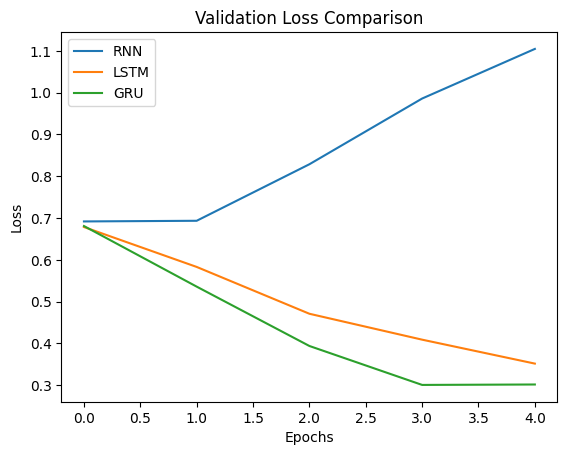

In [ ]:
plt.figure()

plt.plot(rnn_history.history['val_loss'], label='RNN')
plt.plot(lstm_history.history['val_loss'], label='LSTM')
plt.plot(gru_history.history['val_loss'], label='GRU')

plt.title("Validation Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
print("RNN Accuracy:", rnn_model.evaluate(X_test, y_test)[1])
print("LSTM Accuracy:", lstm_model.evaluate(X_test, y_test)[1])
print("GRU Accuracy:", gru_model.evaluate(X_test, y_test)[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5035 - loss: 1.1046
RNN Accuracy: 0.5034999847412109
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.8508 - loss: 0.3518
LSTM Accuracy: 0.8507999777793884
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.8778 - loss: 0.3018
GRU Accuracy: 0.8777999877929688
